In [33]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error,r2_score

In [34]:
datasource= "https://archive.ics.uci.edu/static/public/17/data.csv"

df_BreastCancer = pd.read_csv(datasource, sep=',', header=0) #loading breast cancer dataset
df_BreastCancer.sample(10, random_state=42) #printing random sample of 10 rows
df_BreastCancer["Diagnosis"]=df_BreastCancer["Diagnosis"].map({"M":0, "B":1})
df_BreastCancer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  569 non-null    int64  
 1   radius1             569 non-null    float64
 2   texture1            569 non-null    float64
 3   perimeter1          569 non-null    float64
 4   area1               569 non-null    float64
 5   smoothness1         569 non-null    float64
 6   compactness1        569 non-null    float64
 7   concavity1          569 non-null    float64
 8   concave_points1     569 non-null    float64
 9   symmetry1           569 non-null    float64
 10  fractal_dimension1  569 non-null    float64
 11  radius2             569 non-null    float64
 12  texture2            569 non-null    float64
 13  perimeter2          569 non-null    float64
 14  area2               569 non-null    float64
 15  smoothness2         569 non-null    float64
 16  compactn

Y_predClass [1 0 0 1 1 0 0 0 0 1 1 0 1 0 1 0 1 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0
 1 0 1 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 1 1 1 0 0 1 1 1 0 0 1 1 0 0 1 0
 1 1 1 1 1 1 0 1 1 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 0 1 1 1 0 1 1 0
 1 1 0 1 0 1 1 1 0 1 1 1 0 1 0 0 1 1 0 0 0 1 1 1 0 1 1 1 0 1 0 1]

Linear Regression RMSE: 0.25077977006194757
Linear Regression R squared score:  0.7324078874665129

Accuracy: 0.965034965034965


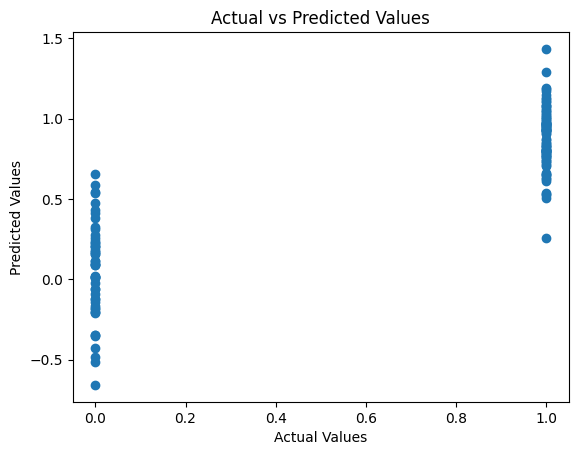

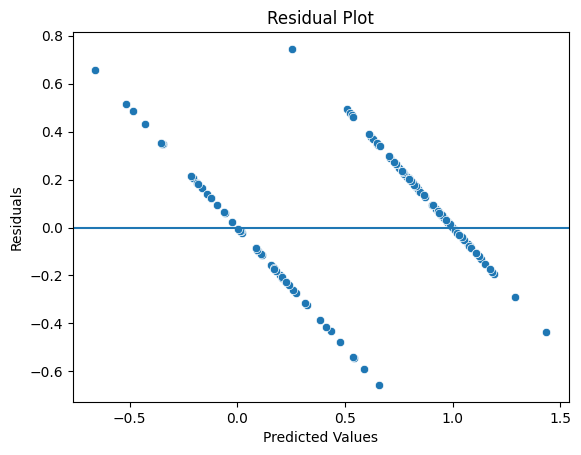

In [35]:
#Performing regular linear Regression:
#Features and Target
X=df_BreastCancer.drop(columns = ["ID","Diagnosis"])
y=df_BreastCancer["Diagnosis"]
#Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

#Linear regression
model1 = LinearRegression()
model1.fit(X_train,y_train)

#Prediction
y_pred=model1.predict(X_test)
#print(y_pred[:20])
y_predClass = (y_pred>0.5).astype(int)
print("Y_predClass",y_predClass)

#Evaluation
model1_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
model1_r2_score = r2_score(y_test, y_pred)
print("\nLinear Regression RMSE:", model1_rmse)
print("Linear Regression R squared score: ", model1_r2_score)

#Accuracy
accuracy = accuracy_score(y_test,y_predClass)
print("\nAccuracy:", accuracy)

#plot the data
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()

residuals = y_test - y_pred
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()



Lasso RMSE: 0.25310364511071937
Lasso R squared score:  0.7274255728803077

Accuracy: 0.958041958041958


               Feature  Coefficient
26          concavity3    -0.095685
20             radius3    -0.077043
21            texture3    -0.016029
22          perimeter3    -0.013252
1             texture1     0.001947
13               area2    -0.001029
23               area3     0.000700
3                area1     0.000370
8            symmetry1    -0.000000
6           concavity1    -0.000000
5         compactness1    -0.000000
0              radius1     0.000000
4          smoothness1    -0.000000
2           perimeter1    -0.000000
12          perimeter2    -0.000000
11            texture2    -0.000000
10             radius2    -0.000000
9   fractal_dimension1    -0.000000
7      concave_points1    -0.000000
17     concave_points2    -0.000000
14         smoothness2    -0.000000
15        compactness2    -0.000000
18           symmetry2    -0.000000
19  fractal_dimension2    -0.0

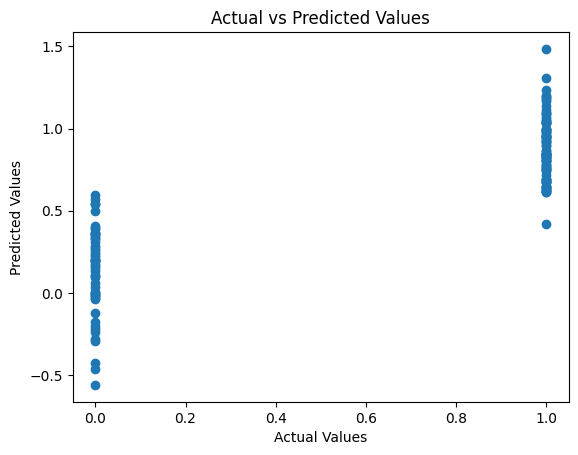

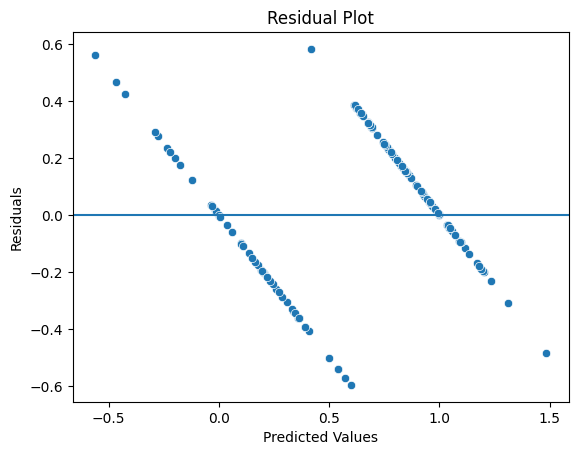

In [36]:
#Linear regression with lasso
model2 = Lasso(alpha = 0.01)
model2.fit(X_train, y_train)

#Prediction
y_pred2 = model2.predict(X_test)
y_predClass2 = (y_pred2>0.5).astype(int)

#Evaluation
lasso_rmse = np.sqrt(mean_squared_error(y_test, y_pred2))
lasso_r2_score = r2_score(y_test, y_pred2)
print("Lasso RMSE:", lasso_rmse)
print("Lasso R squared score: ", lasso_r2_score)

#Accuracy
accuracy = accuracy_score(y_test,y_predClass2)
print("\nAccuracy:", accuracy)
print("\n")

#Feature coefficients:
coef = pd.DataFrame({"Feature": X.columns,
                     "Coefficient": model2.coef_})
print(coef.sort_values("Coefficient", key=abs, ascending=False))

#plot the data
plt.scatter(y_test,y_pred2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()

residuals = y_test - y_pred2
sns.scatterplot(x=y_pred2, y=residuals)
plt.axhline(0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

Ridge RMSE: 0.24180775285970688
Ridge R squared score:  0.7512123884568755

Accuracy: 0.951048951048951


               Feature  Coefficient
26          concavity3    -0.393724
27     concave_points3    -0.371441
28           symmetry3    -0.367640
24         smoothness3    -0.283228
10             radius2    -0.273905
20             radius3    -0.270834
7      concave_points1    -0.259431
16          concavity2     0.214152
0              radius1     0.207680
6           concavity1    -0.186918
4          smoothness1    -0.125540
15        compactness2     0.108198
8            symmetry1    -0.104459
25        compactness3    -0.087540
29  fractal_dimension3    -0.056636
14         smoothness2    -0.042635
5         compactness1     0.041001
18           symmetry2    -0.030479
17     concave_points2    -0.023111
19  fractal_dimension2     0.012194
21            texture3    -0.011889
2           perimeter1    -0.011482
22          perimeter3     0.010174
9   fractal_dimension1    -0.0

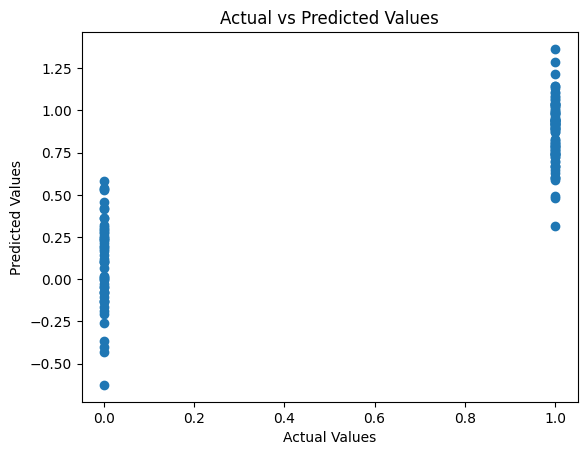

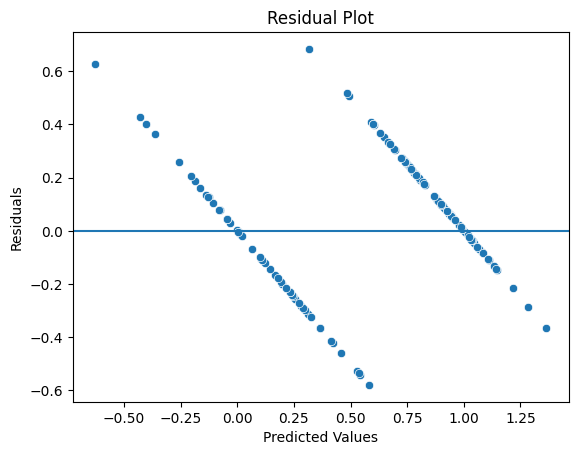

In [37]:
#Linear regression with Ridge
model3 = Ridge(alpha = 1.0)
model3.fit(X_train, y_train)

#Prediction
y_pred3 = model3.predict(X_test)
y_predClass3 = (y_pred3>0.5).astype(int)

#Evaluation
Ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred3))
Ridge_r2_score = r2_score(y_test, y_pred3)
print("Ridge RMSE:", Ridge_rmse)
print("Ridge R squared score: ", Ridge_r2_score)

#Accuracy
accuracy = accuracy_score(y_test,y_predClass3)
print("\nAccuracy:", accuracy)
print("\n")

#Feature coefficients:
coef = pd.DataFrame({"Feature": X.columns,
                     "Coefficient": model3.coef_})
print(coef.sort_values("Coefficient", key=abs, ascending=False))

#plot the data
plt.scatter(y_test,y_pred3)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()

residuals = y_test - y_pred3
sns.scatterplot(x=y_pred3, y=residuals)
plt.axhline(0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

Elastic Net RMSE: 0.2445509400972804
Elastic Net R squared score:  0.7455356296456349

Accuracy: 0.958041958041958


               Feature  Coefficient
26          concavity3    -0.300099
20             radius3    -0.172136
0              radius1     0.100307
21            texture3    -0.015431
12          perimeter2    -0.012548
2           perimeter1    -0.006246
22          perimeter3    -0.003055
1             texture1     0.002186
23               area3     0.000954
13               area2    -0.000380
3                area1    -0.000220
5         compactness1    -0.000000
6           concavity1    -0.000000
4          smoothness1    -0.000000
10             radius2    -0.000000
11            texture2    -0.000000
8            symmetry1    -0.000000
9   fractal_dimension1    -0.000000
7      concave_points1    -0.000000
17     concave_points2    -0.000000
14         smoothness2    -0.000000
15        compactness2    -0.000000
18           symmetry2    -0.000000
19  fractal_dimensi

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.870e+00, tolerance: 9.940e-03
  model = cd_fast.enet_coordinate_descent(


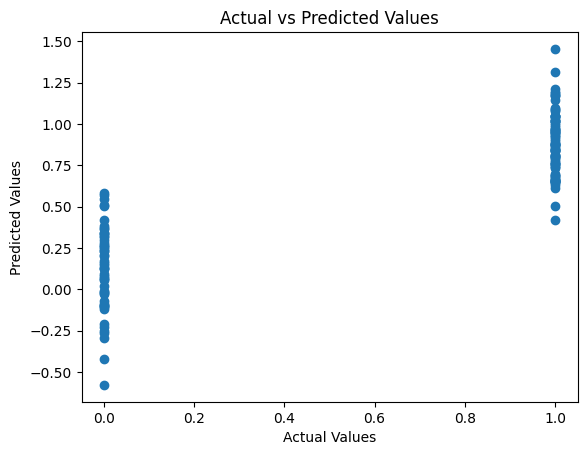

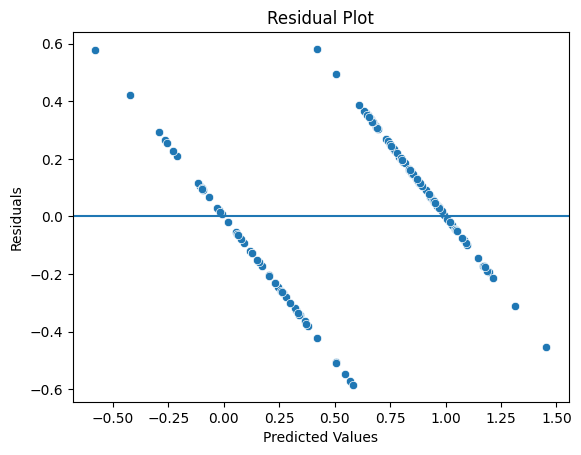

In [38]:
#Linear regression with Ridge
model4 = ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42)
model4.fit(X_train, y_train)

#Prediction
y_pred4 = model4.predict(X_test)
y_predClass4 = (y_pred4>0.5).astype(int)

#Evaluation
enet_rmse = np.sqrt(mean_squared_error(y_test, y_pred4))
enet_r2_score = r2_score(y_test, y_pred4)
print("Elastic Net RMSE:", enet_rmse)
print("Elastic Net R squared score: ", enet_r2_score)

#Accuracy
accuracy = accuracy_score(y_test,y_predClass4)
print("\nAccuracy:", accuracy)
print("\n")

#Feature coefficients:
coef = pd.DataFrame({"Feature": X.columns,
                     "Coefficient": model4.coef_})
print(coef.sort_values("Coefficient", key=abs, ascending=False))

#plot the data
plt.scatter(y_test,y_pred4)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()

residuals = y_test - y_pred4
sns.scatterplot(x=y_pred4, y=residuals)
plt.axhline(0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

Conclusion:
The results indicate that Ridge Regression performed the best, achieving the lowest RMSE(0.2418) and the highest R-square score(0.7512), which means it explained about 75.1% of the variation in the target variable. Elastic net Regression was a close second with an RMSE of 0.2446 and R-square score of 0.7455. Regular Linear regression and Lasso regression showed slightly weaker performance, with Lasso generating RMSE 0.2531 and R-square score of 0.7274. Overall adding L2 regularization through Ridge improved predictive performance, suggesting that shrinking coefficient helped reduce overfitting while rataining important information from the predictors.